In [1]:
import numpy as np
import scipy
from scipy import io
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import torch
import random

In [2]:
import dolfin
from dolfin import *
from mshr import *

## variable coefficient input on 1D Convection-diffusion equation

Setting num :32 // Num Element : 32


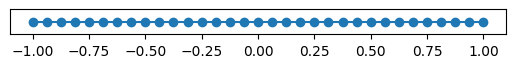

In [3]:
num_x=32
mesh = IntervalMesh(num_x,-1,1)
plot(mesh)
print("Setting num :{} // Num Element : {}".format(num_x, mesh.cells().shape[0]))

In [4]:
import numpy as np
import random
from dolfin import *

def interval_mesh(num_x, num_input, deg_v, deg_f=5, save_mesh=False):
    mesh = IntervalMesh(num_x, -1, 1)
    V = FunctionSpace(mesh, "DG", deg_v)

    bold_v = Constant(0.01)

    h = CellDiameter(mesh)
    n = FacetNormal(mesh)
    alpha = Constant(10.0) / (h('+') + Constant(1e-1))
    

    dS = Measure("dS", domain=mesh)
    ds = Measure("ds", domain=mesh)

    u = TrialFunction(V)
    v = TestFunction(V)

    # --- spaces and geometry info ---
    V0    = FunctionSpace(mesh, "DG", 0)
    V_eps = FunctionSpace(mesh, "DG", 0)
    eps_fun = Function(V_eps)  # will be updated in each sample

    cell_midpoints = np.array([cell.midpoint().x() for cell in cells(mesh)])
    cell_to_dofs   = [V.dofmap().cell_dofs(cell.index()) for cell in cells(mesh)]
    element_edges  = np.linspace(-1, 1, num_x + 1)  # Element boundary locations

    # convection (still constant bold_v, independent of eps)
    c_vol   = bold_v * u.dx(0) * v * dx
    c_flux  = bold_v * jump(u) * avg(v) * dS
    c_bnd   = bold_v * u * v * ds
    convection = assemble(c_vol - c_flux + c_bnd).array()

    # containers
    train_coeff_inputs, train_matrix, train_load_vector = [], [], []
    train_stiff = []   # NEW: diffusion matrices per training sample

    np.random.seed(5)
    for _ in range(num_input[0]):
        # --- random discontinuity locations ---
        x0_idx, x1_idx = sorted(random.sample(range(1, num_x), 2))  # avoid endpoints
        x0, x1 = element_edges[x0_idx], element_edges[x1_idx]

        # ========== f(x): piecewise constant ==========
        f_vals = [1.0, -1.5, 2.5]
        f_array = np.where(cell_midpoints < x0, f_vals[0],
                           np.where(cell_midpoints < x1, f_vals[1], f_vals[2]))
        f_func = Function(V0)
        f_func.vector().set_local(f_array)
        f_func.vector().apply("insert")
        f_proj = interpolate(f_func, V)
        load_vector = assemble(f_proj * v * dx).get_local()
        train_load_vector.append(load_vector.copy())

        # ========== c(x): piecewise constant ==========
        c_ranges = [(0.0, 5.0), (5.0, 10.0), (10.0, 15.0)]
        c_vals = [random.uniform(*r) for r in c_ranges]
        c_array = np.where(cell_midpoints < x0, c_vals[0],
                           np.where(cell_midpoints < x1, c_vals[1], c_vals[2]))
        c_func = Function(V0)
        c_func.vector().set_local(c_array)
        c_func.vector().apply("insert")
        c_proj = interpolate(c_func, V)
        input_matrix = assemble(c_proj * u * v * dx).array()

        # ========== eps(x): discontinuous at SAME x0,x1 ==========
        # choose eps values for the three subdomains (fixed or random)
        eps_vals = [0.01, 0.02, 0.03]  # or random.uniform(...) if you want randomness
        eps_array = np.where(cell_midpoints < x0, eps_vals[0],
                             np.where(cell_midpoints < x1, eps_vals[1], eps_vals[2]))
        eps_fun.vector().set_local(eps_array)
        eps_fun.vector().apply("insert")

        # SIPG stiffness matrix with this eps(x)
        a_DG = (
            eps_fun * u.dx(0) * v.dx(0) * dx
            - (dot(avg(eps_fun * grad(u)), jump(v, n)) +
               dot(avg(eps_fun * grad(v)), jump(u, n))) * dS
            + avg(eps_fun) * alpha * inner(jump(u), jump(v)) * dS
            - eps_fun * (dot(grad(u), n) * v + u * dot(grad(v), n)) * ds
            + eps_fun * (Constant(10.0) / (h + Constant(1e-10))) * u * v * ds
        )
        stiff_local = assemble(a_DG).array()
        train_stiff.append(stiff_local)

        train_coeff_inputs.append(np.array(c_vals + [x0, x1]))
        train_matrix.append(input_matrix)

    # ----- Validation data -----
    validate_coeff_inputs, validate_matrix, validate_load_vector = [], [], []
    validate_stiff = []  # NEW

    np.random.seed(10)
    for _ in range(num_input[1]):
        x0_idx, x1_idx = sorted(random.sample(range(1, num_x), 2))
        x0, x1 = element_edges[x0_idx], element_edges[x1_idx]

        f_vals = [1.0, -1.5, 2.5]
        f_array = np.where(cell_midpoints < x0, f_vals[0],
                           np.where(cell_midpoints < x1, f_vals[1], f_vals[2]))
        f_func = Function(V0)
        f_func.vector().set_local(f_array)
        f_func.vector().apply("insert")
        f_proj = interpolate(f_func, V)
        load_vector = assemble(f_proj * v * dx).get_local()
        validate_load_vector.append(load_vector.copy())

        c_ranges = [(0.0, 5.0), (5.0, 10.0), (10.0, 15.0)]
        c_vals = [random.uniform(*r) for r in c_ranges]
        c_array = np.where(cell_midpoints < x0, c_vals[0],
                           np.where(cell_midpoints < x1, c_vals[1], c_vals[2]))
        c_func = Function(V0)
        c_func.vector().set_local(c_array)
        c_func.vector().apply("insert")
        c_proj = interpolate(c_func, V)
        input_matrix = assemble(c_proj * u * v * dx).array()

        # eps(x) for validation sample (same logic as training)
        eps_vals = [0.01, 0.02, 0.03]
        eps_array = np.where(cell_midpoints < x0, eps_vals[0],
                             np.where(cell_midpoints < x1, eps_vals[1], eps_vals[2]))
        eps_fun.vector().set_local(eps_array)
        eps_fun.vector().apply("insert")

        a_DG = (
            eps_fun * u.dx(0) * v.dx(0) * dx
            - (dot(avg(eps_fun * grad(u)), jump(v, n)) +
               dot(avg(eps_fun * grad(v)), jump(u, n))) * dS
            + avg(eps_fun) * alpha * inner(jump(u), jump(v)) * dS
            - eps_fun * (dot(grad(u), n) * v + u * dot(grad(v), n)) * ds
            + eps_fun * (Constant(10.0) / (h + Constant(1e-10))) * u * v * ds
        )
        stiff_local = assemble(a_DG).array()
        validate_stiff.append(stiff_local)

        validate_coeff_inputs.append(np.array(c_vals + [x0, x1]))
        validate_matrix.append(input_matrix)

    # Coordinates and connectivity
    ne = mesh.num_cells()
    p  = V.tabulate_dof_coordinates().reshape(-1)
    ng = p.shape[0]
    c  = np.asarray([V.dofmap().cell_dofs(i) for i in range(ne)])

    if save_mesh:
        np.save('mesh_CG.npy', p)

    return (
        ne, ng, p, c,
        np.array(train_stiff),        # all diffusion matrices (eps-dependent)
        convection,
        np.array(train_load_vector),
        np.array(validate_load_vector),
        np.array(train_coeff_inputs),
        np.array(train_matrix),
        np.array(validate_coeff_inputs),
        np.array(validate_matrix),
        np.array(validate_stiff),     # optional: validation diffusion matrices
    )


In [5]:
order2=1
list_ne=[32]
num_input=[1000, 1000]
typ='inputcoeff'
print(list_ne)

[32]


In [7]:
import os
import numpy as np

# Ensure the directory exists before saving
save_dir = 'mesh_1DP{}'.format(order2)  # Construct directory name
os.makedirs(save_dir, exist_ok=True)  # Create directory if it doesn't exist

# Iterate over mesh sizes and save data
for idx, num in enumerate(list_ne):
    ne, ng, p, c, train_stiff, convection, train_load_vector,validate_load_vector, train_coeff_inputs, train_matrix, validate_coeff_inputs, validate_matrix, validate_stiff = interval_mesh(num, num_input, deg_v=order2)

    # Save data
    np.savez('{}/ne{}_{}.npz'.format(save_dir, list_ne[idx], typ),
             ne=ne, ng=ng, p=p, c=c, train_stiff=train_stiff, convection=convection, 
             train_load_vector=train_load_vector, validate_load_vector=validate_load_vector,train_coeff_inputs=train_coeff_inputs, 
             train_matrix=train_matrix, validate_coeff_inputs=validate_coeff_inputs, 
             validate_matrix=validate_matrix, validate_stiff=validate_stiff)
